# notebooks/training_logs.ipynb

### Logs training and validation curves, and training run produced reports/training/training_run.log plus reports/training/training_summary.json.

## 1. Setup

In [1]:
from pathlib import Path
import json
import ast
import re

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
TRAINING_REPORTS = ROOT / "reports" / "training"

summary_path = TRAINING_REPORTS / "training_summary.json"
dataset_path = TRAINING_REPORTS / "dataset_summary.json"
log_path = TRAINING_REPORTS / "training_run.log"

assert summary_path.exists(), f"Missing: {summary_path}"
assert dataset_path.exists(), f"Missing: {dataset_path}"
assert log_path.exists(), f"Missing: {log_path}"

summary = json.loads(summary_path.read_text(encoding="utf-8"))
dataset_summary = json.loads(dataset_path.read_text(encoding="utf-8"))

summary, dataset_summary

({'status': 'complete',
  'base_model': 'unsloth/Llama-3.2-1B-Instruct-bnb-4bit',
  'model_dir': 'models/judge',
  'checkpoint_dir': 'models/checkpoints',
  'report_dir': 'reports/training',
  'train_pairs': 65,
  'validation_pairs': 39,
  'train_metrics': {'train_runtime': 46.6419,
   'train_samples_per_second': 1.394,
   'train_steps_per_second': 0.364,
   'total_flos': 0.0,
   'train_loss': 0.6785038884948281,
   'epoch': 1.0},
  'eval_metrics': {'eval_loss': 0.6711041331291199,
   'eval_runtime': 6.2784,
   'eval_samples_per_second': 6.212,
   'eval_steps_per_second': 6.212,
   'eval_rewards/chosen': 0.03396207466721535,
   'eval_rewards/rejected': -0.01113205123692751,
   'eval_rewards/accuracies': 0.9487179517745972,
   'eval_rewards/margins': 0.04509412497282028,
   'eval_logps/chosen': -165.6200408935547,
   'eval_logps/rejected': -101.88105010986328,
   'eval_logits/chosen': 1.8221752643585205,
   'eval_logits/rejected': 1.3276885747909546,
   'epoch': 1.0},
  'runtime_seconds

## 2. Parse log metrics

In [2]:
records = []

with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if "{'loss':" in line or "{'eval_loss':" in line or "{'train_runtime':" in line:
            start = line.find("{")
            end = line.rfind("}")
            if start != -1 and end != -1 and end > start:
                raw = line[start:end+1]
                try:
                    record = ast.literal_eval(raw)
                    records.append(record)
                except Exception:
                    pass

log_df = pd.DataFrame(records)
log_df

,loss,grad_norm,learning_rate,rewards/chosen,rewards/rejected,rewards/accuracies,rewards/margins,logps/chosen,logps/rejected,logits/chosen,...,eval_rewards/accuracies,eval_rewards/margins,eval_logps/chosen,eval_logps/rejected,eval_logits/chosen,eval_logits/rejected,train_runtime,train_samples_per_second,train_steps_per_second,train_loss
0,0.6931,4.941075,0.000000e+00,0.000000,0.000000,0.00,0.000000,-213.820862,-143.791840,1.769450,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.6931,4.610219,2.500000e-06,0.000000,0.000000,0.00,0.000000,-168.149231,-117.060074,1.850350,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.6938,4.706829,5.000000e-06,-0.001504,-0.000175,0.50,-0.001329,-123.264954,-98.524002,1.997175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.6877,5.312809,4.666667e-06,0.003865,-0.007056,1.00,0.010921,-246.011597,-164.128601,1.783793,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.6887,3.457620,4.333333e-06,0.005802,-0.003065,1.00,0.008866,-124.236740,-95.333359,1.870191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.6867,4.559229,4.000000e-06,0.010657,-0.002493,0.50,0.013150,-193.089478,-114.090767,1.708640,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.6826,4.125182,3.666667e-06,0.013381,-0.007996,0.75,0.021377,-191.671768,-116.613373,1.912983,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.6901,4.763878,3.333333e-06,0.007228,0.001207,1.00,0.006021,-163.710266,-141.744278,1.738679,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.6804,5.838153,3.000000e-06,0.022673,-0.002929,1.00,0.025602,-192.805252,-77.465256,1.708063,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.6830,3.817335,2.666667e-06,0.015830,-0.004639,1.00,0.020469,-152.790771,-102.229347,2.047784,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Training curve

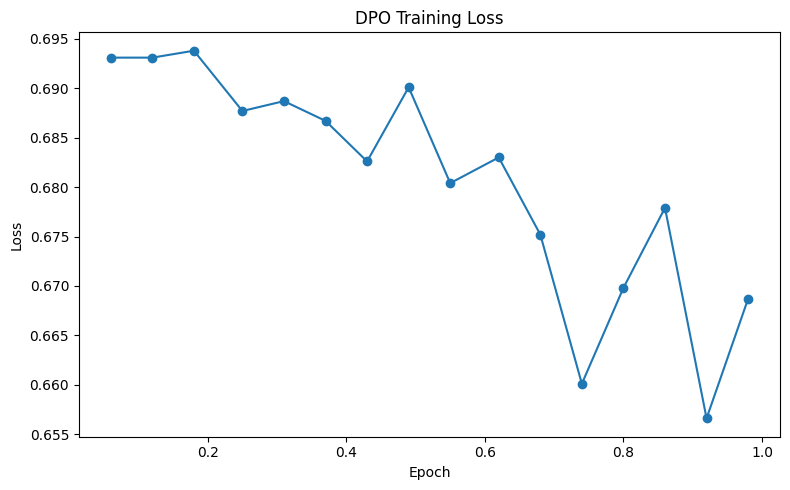

Saved: ..\reports\training\training_loss_curve.png


In [3]:
train_df = log_df[log_df["loss"].notna()].copy()

if not train_df.empty:
    ax = train_df.plot(x="epoch", y="loss", marker="o", figsize=(8, 5), legend=False)
    ax.set_title("DPO Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    plt.tight_layout()

    out = TRAINING_REPORTS / "training_loss_curve.png"
    plt.savefig(out, dpi=160)
    plt.show()
    print(f"Saved: {out}")
else:
    print("No per-step training loss rows found.")

## 4. Reward metrics

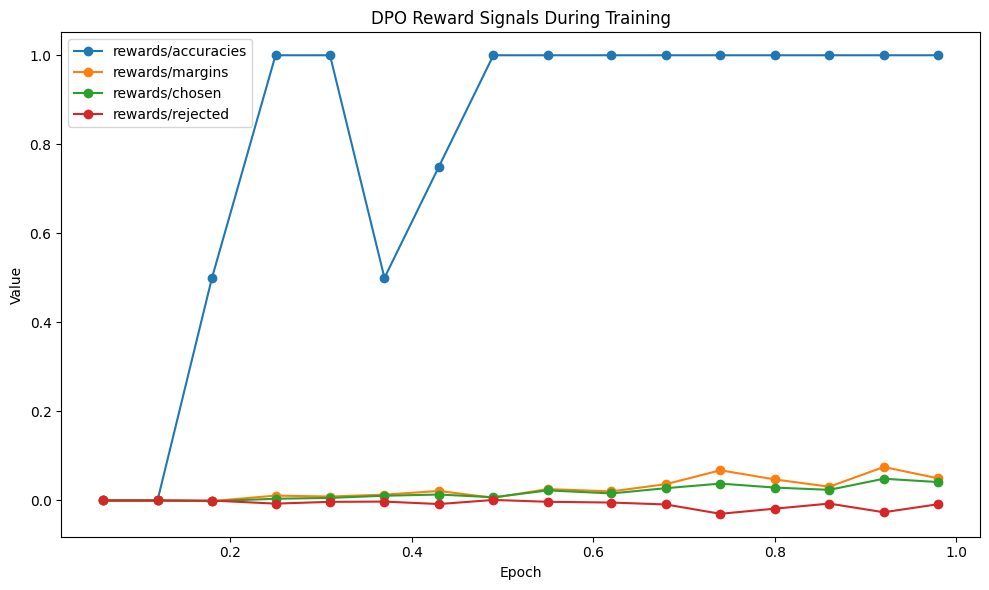

Saved: ..\reports\training\training_reward_curves.png


In [4]:
reward_cols = [
    "rewards/accuracies",
    "rewards/margins",
    "rewards/chosen",
    "rewards/rejected",
]

available = [c for c in reward_cols if c in train_df.columns]

if available:
    ax = train_df.plot(x="epoch", y=available, marker="o", figsize=(10, 6))
    ax.set_title("DPO Reward Signals During Training")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Value")
    plt.tight_layout()

    out = TRAINING_REPORTS / "training_reward_curves.png"
    plt.savefig(out, dpi=160)
    plt.show()
    print(f"Saved: {out}")
else:
    print("No reward columns found.")

## 5. Final training summary

In [5]:
training_log_summary = {
    "dataset": dataset_summary,
    "training_summary": summary,
    "parsed_training_steps": len(train_df),
    "final_train_loss": summary.get("train_metrics", {}).get("train_loss"),
    "final_eval_loss": summary.get("eval_metrics", {}).get("eval_loss"),
    "final_eval_reward_accuracy": summary.get("eval_metrics", {}).get("eval_rewards/accuracies"),
    "final_eval_reward_margin": summary.get("eval_metrics", {}).get("eval_rewards/margins"),
}

out = TRAINING_REPORTS / "training_log_summary.json"
with open(out, "w", encoding="utf-8") as f:
    json.dump(training_log_summary, f, indent=2, ensure_ascii=False)

training_log_summary

{'dataset': {'train_file': 'data/training_data/preferences_train.jsonl',
  'dev_file': 'data/training_data/preferences_dev.jsonl',
  'train_pairs': 65,
  'validation_pairs': 39,
  'columns': ['prompt', 'chosen', 'rejected']},
 'training_summary': {'status': 'complete',
  'base_model': 'unsloth/Llama-3.2-1B-Instruct-bnb-4bit',
  'model_dir': 'models/judge',
  'checkpoint_dir': 'models/checkpoints',
  'report_dir': 'reports/training',
  'train_pairs': 65,
  'validation_pairs': 39,
  'train_metrics': {'train_runtime': 46.6419,
   'train_samples_per_second': 1.394,
   'train_steps_per_second': 0.364,
   'total_flos': 0.0,
   'train_loss': 0.6785038884948281,
   'epoch': 1.0},
  'eval_metrics': {'eval_loss': 0.6711041331291199,
   'eval_runtime': 6.2784,
   'eval_samples_per_second': 6.212,
   'eval_steps_per_second': 6.212,
   'eval_rewards/chosen': 0.03396207466721535,
   'eval_rewards/rejected': -0.01113205123692751,
   'eval_rewards/accuracies': 0.9487179517745972,
   'eval_rewards/marg